# Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

from VirtualSAS_theory import VirtualSAS_theory

from AFL.double_agent import *
from AFL.double_agent.GPyTorchExtrapolator import DirichletGPExtrapolator 

from tqdm.auto import tqdm

## Load Boundary Dataset

In [3]:
boundary_dataset = xr.load_dataset('250610-extrap_expand_dataset.nc')
boundary_dataset

<xarray.Dataset> Size: 500kB
Dimensions:      (component: 3, sample: 15625)
Coordinates:
  * component    (component) <U11 132B 'protein' 'temperature' 'glycerol'
Dimensions without coordinates: sample
Data variables:
    composition  (component, sample) float64 375kB -3.507 -3.507 ... 9.008 9.558
    labels       (sample) int64 125kB 0 0 0 0 0 0 0 0 0 0 ... 2 2 2 2 2 2 2 2 2
Attributes:
    labels:          labels
    components:      composition
    components_dim:  component

In [4]:
boundary_dataset.close()

## Instantiate Instrument and Draw Boundaries

In [5]:
from AFL.automation.APIServer.data.DataTrashcan import DataTrashcan

reference_data_path = './SANS/'
inst_client = VirtualSAS_theory()
inst_client.data = DataTrashcan()
boundary_dataset['labels'] = boundary_dataset.labels.astype(str)
inst_client.boundary_dataset = boundary_dataset
inst_client.trace_boundaries(hull_tracing_ratio=0.25)


## Add sasmodels

In [6]:
# specify reference data
for fname in ['low_q.ABS', 'med_q.ABS', 'high_q.ABS']:
    data = pd.read_csv(str(pathlib.Path(reference_data_path) / fname),sep=r'\s+')#, delim_whitespace=True)
    inst_client.add_configuration(
        q=list(data.q),
        I=list(data.I),
        dI=list(data.dI),
        dq=list(data.dq),
        reset=False
    )

inst_client.add_sasview_model(
    label='2',
    model_name='polymer_excl_volume',
    model_kw={
        'scale': 1.0,
        'background': 1.0,
        'rg': 100.0,
    }
)

inst_client.add_sasview_model(
    label='1',
    model_name='sphere',
    model_kw={
        'scale': 0.5,
        'background': 1.0,
        'sld': 1.0,
        'sld_solvent': 6.0,
        'radius': 10,
    }
)

inst_client.add_sasview_model(
    label='0',
    model_name='power_law',
    model_kw={
        'scale': 1e-7,
        'background': 1.0,
        'power': 4.0,
    }
)
inst_client

## Test Virtual Instrument

In [7]:
ds_list = []
for temp in [0,10,20,30,40,50]:
    ds = inst_client.simple_expose({'protein':40,'temperature':temp,'glycerol':5})
    ds['labels'] = ds.attrs['labels']
    ds_list.append(ds)

ds = xr.concat(ds_list,dim='sample')
ds

<xarray.Dataset> Size: 43kB
Dimensions:      (sample: 6, q: 281, component: 3)
Coordinates:
  * q            (q) float64 2kB 0.003836 0.004348 0.004859 ... 0.6293 0.6334
  * component    (component) <U11 132B 'protein' 'temperature' 'glycerol'
Dimensions without coordinates: sample
Data variables:
    I            (sample, q) float64 13kB 1.95 1.937 1.923 1.907 ... 1.0 1.0 1.0
    I_noiseless  (sample, q) float64 13kB 1.95 1.937 1.923 1.907 ... 1.0 1.0 1.0
    dI           (sample, q) float64 13kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    composition  (sample, component) int64 144B 40 0 5 40 10 5 ... 40 5 40 50 5
    labels       (sample) <U1 24B '2' '1' '1' '1' '0' '0'
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

# Virtual Active Learning

## Initial Dataset

In [8]:
ds_list = []
for temp in [0,10,20,30,40,50]:
    ds = inst_client.simple_expose({'protein':40,'temperature':temp,'glycerol':5})
    ds_list.append(ds)

ds_init = xr.concat(ds_list, dim='sample')
ds_init

<xarray.Dataset> Size: 43kB
Dimensions:      (sample: 6, q: 281, component: 3)
Coordinates:
  * q            (q) float64 2kB 0.003836 0.004348 0.004859 ... 0.6293 0.6334
  * component    (component) <U11 132B 'protein' 'temperature' 'glycerol'
Dimensions without coordinates: sample
Data variables:
    I            (sample, q) float64 13kB 1.95 1.937 1.923 1.907 ... 1.0 1.0 1.0
    I_noiseless  (sample, q) float64 13kB 1.95 1.937 1.923 1.907 ... 1.0 1.0 1.0
    dI           (sample, q) float64 13kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    composition  (sample, component) int64 144B 40 0 5 40 10 5 ... 40 5 40 50 5
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

### Construct a cost model for the design space 

We are interested in querying a design space $\mathcal{X}$, to find an underlying function $f(x)$ that labels any given point $x \in \mathcal{X}$. Our design sampling criteria is defined by a Gaussian Process model that takes the discrete label outputs of $f(x) = y \in \{0,1,2,3...,d\}$ and turns them into probabilities over each label $p(y = d | x)$. 

In traditional active learning setting with the above mathematical setup assuming the cost to evaluate points across different components of $\mathcal{X}$ to be the same, we would devise a sampling strategy based on entropy of the probabilistic outputs of the GP. A typical stragety is to sample points in $\mathcal{X}$ that have the maximum entropy--leading to a decision closer to the percieved boundary. 

In presence of an associated, heterogenous cost to each `dimension` of $\mathcal{X}$, we can use cost per unit approach originally presented [here](https://papers.nips.cc/paper_files/paper/2012/hash/05311655a15b75fab86956663e1819cd-Abstract.html), that simply scales the acquisition criteria by the cost per each sample. Using this formalism, we get:
$$ \mathrm{Entropy}_{\mathrm{pu}} := \frac{\mathrm{Entropy}(x)}{C(x)} $$

This serves as a baseline approach where we can pre-specify a cost function and use it to bias our design sampling to be effective to certain costs or penalties inherent to sampling the design space. This also requires only single change to the exisiting pipeline that computes the acquisition cost per unit or sample which is then passed onto a active learning selector.

In [9]:
import sympy

T, dT = sympy.symbols('T dT')

# Constants
alpha_h = 0.05
alpha_c = 0.45
tow_s = 0.25
beta = 0.25
T_thresh = 40.0
T_scale = 5.0


# Component 2: Heating cost (only when T > T_base)
C_heat = alpha_h * sympy.Piecewise((0, dT <= 0), (dT, dT > 0))

# Component 3: Cooling cost (only when T < T_base)
C_cool = alpha_c * sympy.Piecewise((0, dT >= 0), (-dT, dT < 0))

# Component 4: Degradation cost (only when T > T_thresh)
C_deg = beta * sympy.Piecewise(
    (0, T <= T_thresh),
    ((T - T_thresh) / T_scale, T > T_thresh)
)



In [10]:
C_heat

0.05*Piecewise((0, dT <= 0), (dT, True))

In [11]:
C_cool

0.45*Piecewise((0, dT >= 0), (-dT, True))

In [12]:
C_deg

0.25*Piecewise((0, T <= 40.0), (0.2*T - 8.0, True))

In [13]:
# PipelineOp for cost-aware acquisition 
class CompositionTemperatureActionCost(PipelineOp):
    """A post-processing `PipelineOp` that computes cost of evaluating a data point.

    Parameters
    ----------
    input_variable : str
        The name of the `xarray.Dataset` data variable to extract from the input dataset
    grid_variable: str
        The name of the `xarray.Dataset` data variable to use as a evaluation grid.
    grid_dim: str
        The name of the `xarray.Dataset` data variable to use as a evaluation grid.
    grid_variable: str
        The name of the `xarray.Dataset` data variable to use as a evaluation grid.
    grid_variable: str
        The name of the `xarray.Dataset` data variable to use as a evaluation grid.        
    output_variable : str
        The name of the variable to be inserted into the `xarray.Dataset` by this `PipelineOp`
    name : str
        The name to use when added to a Pipeline. This name is used when calling Pipeline.search()
    """

    def __init__(
        self,
        input_variable: str = None,
        sample_dim: str = None,
        grid_variable: str = None,
        grid_dim: str = "grid",
        composition_variable: Optional[List[str]] = None,
        temperature_variable: str=None,
        output_variable: str = None,
        name: str = "CompositionTemperatureActionCost",
    ) -> None:
        super().__init__(
            name=name, input_variable=[input_variable, grid_variable], output_variable=output_variable
        )
        self.sample_dim = sample_dim
        self.grid_variable = grid_variable
        self.grid_dim = grid_dim
        self.composition_variable = composition_variable
        self.temperature_variable = temperature_variable

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Apply this `PipelineOp` to the supplied `xarray.dataset`"""
        data = dataset[self.input_variable]
        grid = dataset[self.grid_variable]

        t_sampled = data.sel(component=self.temperature_variable).values
        results = []
        for comp in self.composition_variable: # type: ignore
            selected = data.sel(component=comp).values
            results.append(selected)

        c_sampled = np.asarray(results).T

        t_grid = grid.sel(component=self.temperature_variable).values
        results = []
        for comp in self.composition_variable: # type: ignore
            selected = grid.sel(component=comp).values
            results.append(selected)

        c_grid = np.asarray(results).T

        cost_grid = np.zeros(grid.shape[0])
        for i in range(grid.shape[0]):
            # check if this composition is in the sampled data
            if np.any(np.all(grid.values[i,:] == data.values, axis=1)):
                cost = 0.0

            # if the composition is in the sampled data, but the temperature is not
            elif np.any(np.all(c_sampled == c_grid[i], axis=1)):
                flags = np.all(c_sampled == c_grid[i], axis=1)
                if flags.sum() > 1:
                    indx = ((t_sampled - t_grid[i])**2).argmin()
                else:
                    indx = np.argwhere(flags)

                # since we have the composition, the synthesis cost is 0    
                cost_synthesis = 0.0

                # Cost to heat or cool to the desired temperature is dependent on 
                # the delta T
                delta_t = t_grid[i] - t_sampled[indx]
                # if we need to heat or cool the cost is linear
                if delta_t < 0:
                    cost_temperature = -delta_t * 50.0  # Cooling cost
                else:
                    cost_temperature = delta_t * 25.0  # Heating cost
                # Degradation cost
                if t_grid[i] > 40.0:
                    cost_deg = 10.0 * ((t_grid[i] - 40.0) / 5.0)
                else:
                    cost_deg = 0.0

                cost = (cost_synthesis + cost_temperature + cost_deg).item()

            # if it is a completely new composition and temperature
            else:
                cost_synthesis = sum(c_grid[i])

                # delta T is relative to room temperature (27C)
                delta_t = t_grid[i] - 27.0
                # if we need to heat or cool the cost is linear
                if delta_t < 0:
                    cost_temperature = -delta_t * 50.0  # Cooling cost
                else:
                    cost_temperature = delta_t * 25.0  # Heating cost
                # Degradation cost
                if t_grid[i] > 40.0:
                    cost_deg = 10.0 * ((t_grid[i] - 40.0) / 5.0)
                else:
                    cost_deg = 0.0

                cost = (cost_synthesis + cost_temperature + cost_deg).item()

            cost_grid[i] = cost

        norm_cost_grid = self.minmax_normalize(cost_grid)
        self.output[self.output_variable] = xr.DataArray(norm_cost_grid, dims=self.grid_dim)
        self.output[self.output_variable].attrs[
            "description"
        ] = "Cost per sample (normalized) evaluated on %s"%self.grid_variable

        return self 
    
    def minmax_normalize(self, x : np.ndarray) -> np.ndarray:
        """Normalizes an array to [0,1]"""
        return (x - x.min()) / (x.max() - x.min() + 1e-9)

In [14]:
class AcquisitonPerUnitCost(PipelineOp):
    """A post-processing `PipelineOp` that computes acqusition per unit cost.

    Parameters
    ----------
    input_variable : str
        The name of the `xarray.Dataset` data variable to extract from the input dataset
    grid_variable: str
        The name of the `xarray.Dataset` data variable to use as a evaluation grid.
    output_variable : str
        The name of the variable to be inserted into the `xarray.Dataset` by this `PipelineOp`
    name : str
        The name to use when added to a Pipeline. This name is used when calling Pipeline.search()
    """

    def __init__(
        self,
        input_variable: str = None,
        cost_variable: str = None,
        grid_dim: str = "grid",
        output_variable: str = None,
        name: str = "AcquisitonPerUnitCost",
    ) -> None:
        super().__init__(
            name=name, input_variable=[input_variable, cost_variable], output_variable=output_variable
        )
        self.cost_variable = cost_variable
        self.grid_dim = grid_dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Apply this `PipelineOp` to the supplied `xarray.Dataset` using xarray operations only."""

        acqv = dataset[self.input_variable]
        cost = dataset[self.cost_variable]

        # Compute acquisition per unit cost
        acqv_pu = acqv / (cost + 1e-9)
        # Add acquisition and acquiring cost
        # This reduces the absurd case of sampling existing points with zero cost
        acqv_pu = 8*acqv - 2*cost

        # Normalize
        # norm_acqv_pu = (acqv_pu - acqv_pu.min()) / (acqv_pu.max() - acqv_pu.min() + 1e-9)

        # Store result
        self.output[self.output_variable] = acqv_pu
        self.output[self.output_variable].attrs["description"] = "Acquisition Per Unit Cost (Normalized)"

        return self


### Creatte the pipeline for active learning

In [15]:
with Pipeline(name = "find_boundaries") as p:
    CartesianGrid(
        output_variable="composition_grid",
        sample_dim="grid",
        grid_spec = {'protein':{'min': 0.0, 'max': 80.0, 'steps': 25},
                     'glycerol':{'min': 0.0, 'max': 12.0, 'steps': 25},
                     'temperature':{'min': 0.0, 'max': 50.0, 'steps': 25}}
    )

    Standardize(
        input_variable="composition",
        output_variable="normalized_composition",
        dim="sample",
        component_dim="component",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )

    Standardize(
        input_variable="composition_grid",
        output_variable="normalized_composition_grid",
        dim="grid",
        component_dim="component",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )

    SavgolFilter(
        input_variable="I",
        output_variable="derivative0",
        dim="q",
        xlo=None,
        xhi=None,
        xlo_isel=None,
        xhi_isel=None,
        pedestal=None,
        npts=250,
        derivative=0,
        window_length=31,
        polyorder=2,
        apply_log_scale=True,
        name="SavgolFilter",
    )

    SavgolFilter(
        input_variable="I",
        output_variable="derivative1",
        dim="q",
        xlo=None,
        xhi=None,
        xlo_isel=None,
        xhi_isel=None,
        pedestal=None,
        npts=250,
        derivative=1,
        window_length=31,
        polyorder=2,
        apply_log_scale=True,
        name="SavgolFilter",
    )

    Similarity(
        input_variable="derivative0",
        output_variable="similarity0",
        sample_dim="sample",
        params={'metric': 'laplacian', 'gamma': 0.0025},
        constrain_same=[],
        constrain_different=[],
        name="SimilarityMetric",
    )

    Similarity(
        input_variable="derivative1",
        output_variable="similarity1",
        sample_dim="sample",
        params={'metric': 'laplacian', 'gamma': 0.0025},
        constrain_same=[],
        constrain_different=[],
        name="SimilarityMetric",
    )

    CombineMetric(
        input_variables=['similarity0','similarity1'],
        output_variable="similarity",
        sample_dim="sample",
        combine_by="sum",
        combine_by_powers=None,
        combine_by_coeffs=None,
        name="CombineMetric",
    )

    SpectralClustering(
        input_variable="similarity",
        output_variable="labels",
        dim="sample",
        params={'n_phases': 3},
        name="SpectralClustering",
        use_silhouette=False,
    )
    
    DirichletGPExtrapolator(
        feature_input_variable="normalized_composition",
        predictor_input_variable="labels",
        output_prefix="extrap",
        grid_variable="normalized_composition_grid",
        grid_dim="grid",
        sample_dim="sample",
        params={"learning_rate": 1e-1, "n_iterations": 500, "verbose": False},
        name="DirichletGPExtrapolator",
    )
    CompositionTemperatureActionCost(
        input_variable="composition",
        sample_dim="sample",
        grid_variable="composition_grid",
        grid_dim="grid",
        temperature_variable="temperature",
        composition_variable=['protein', 'glycerol'],
        output_variable="cost",
        name="CompositionTemperatureActionCost",
    )
    AcquisitonPerUnitCost(
        input_variable="extrap_entropy",
        cost_variable="cost",
        grid_dim="grid",        
        output_variable="acqv_pu",
        name="AcquisitonPerUnitCost",
    )    
    MaxValueAF(
        input_variables=['acqv_pu'],
        grid_variable="composition_grid",
        grid_dim="grid",
        combine_coeffs=None,
        output_prefix=None,
        output_variable="next_sample",
        decision_rtol=0.05,
        excluded_comps_variables=None,
        excluded_comps_dim=None,
        exclusion_radius=0.001,
        count=1,
        name="MaxValueAF",
    )

p.print()

PipelineOp                               input_variable ---> output_variable
----------                               -----------------------------------
0  ) <CartesianGridGenerator>            CartesianGridGenerator ---> composition_grid
1  ) <Standardize>                       composition ---> normalized_composition
2  ) <Standardize>                       composition_grid ---> normalized_composition_grid
3  ) <SavgolFilter>                      I ---> derivative0
4  ) <SavgolFilter>                      I ---> derivative1
5  ) <SimilarityMetric>                  derivative0 ---> similarity0
6  ) <SimilarityMetric>                  derivative1 ---> similarity1
7  ) <CombineMetric>                     ['similarity0', 'similarity1'] ---> similarity
8  ) <SpectralClustering>                similarity ---> labels
9  ) <DirichletGPExtrapolator>           ['normalized_composition', 'labels', 'normalized_composition_grid'] ---> ['extrap_y_prob']
10 ) <CompositionTemperatureActionCost>  com

In [16]:
def plot_value_slices(ds, value_name):
    composition_grid = ds_result.composition_grid.values
    values = ds[value_name].values

    fig, axs = plt.subplots(2,3, figsize=(4*3, 4*2))
    fig.subplots_adjust(wspace=0.3, hspace=0.3)
    axs = axs.flatten()
    norm = mcolors.Normalize(vmin=values.min(), vmax=values.max())
    cmap = plt.get_cmap('coolwarm') 
    mappable = ScalarMappable(norm=norm, cmap=cmap)

    for i, value in enumerate(np.arange(0, 51, 10)):
        flags = np.isclose(composition_grid[:,1], value, atol=1.0)
        ax = axs[i]
        ax.tricontourf(composition_grid[flags,0],
                    composition_grid[flags,2],
                    values[flags],
                    cmap = cmap,
                    norm = norm
                    )
        ax.set_xlabel("Protein")
        ax.set_title("Temperature = %d"%value)
        
    axs[0].set_ylabel("Glycerol")
    cax = fig.add_axes([0.95, 0.3, 0.02, 0.4])  # [left, bottom, width, height]
    cbar = fig.colorbar(mappable, shrink=0.5, aspect=5, cax=cax)
    plt.show()

### Test Pipeline

In [17]:
ds_result = p.calculate(ds_init)
ds_result

  0%|          | 0/13 [00:00<?, ?it/s]

<xarray.Dataset> Size: 2MB
Dimensions:                      (q: 281, component: 3, sample: 6, grid: 15625,
                                  log_q: 250, sample_i: 6, sample_j: 6,
                                  AF_sample: 1)
Coordinates:
  * q                            (q) float64 2kB 0.003836 0.004348 ... 0.6334
  * component                    (component) object 24B 'protein' ... 'glycerol'
  * log_q                        (log_q) float64 2kB -2.416 -2.407 ... -0.1983
Dimensions without coordinates: sample, grid, sample_i, sample_j, AF_sample
Data variables: (12/20)
    I                            (sample, q) float64 13kB 1.95 1.937 ... 1.0 1.0
    I_noiseless                  (sample, q) float64 13kB 1.95 1.937 ... 1.0 1.0
    dI                           (sample, q) float64 13kB 0.0 0.0 ... 0.0 0.0
    composition                  (sample, component) int64 144B 40 0 5 ... 50 5
    composition_grid             (grid, component) float64 375kB 0.0 ... 12.0
    normalized_composition       (sample, component) float64 144B 0.5 ... 0.4167
    ...                           ...
    extrap_entropy               (grid) float64 125kB 0.8362 0.8349 ... 0.8431
    extrap_y_prob                (grid) float64 125kB 0.8362 0.8349 ... 0.8431
    cost                         (grid) float64 125kB 0.9362 0.864 ... 0.4764
    acqv_pu                      (grid) float64 125kB 4.817 4.951 ... 5.792
    decision_surface             (grid) float64 125kB 0.6003 0.6258 ... 0.7858
    next_sample                  (AF_sample, component) float64 24B 13.33 ......
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

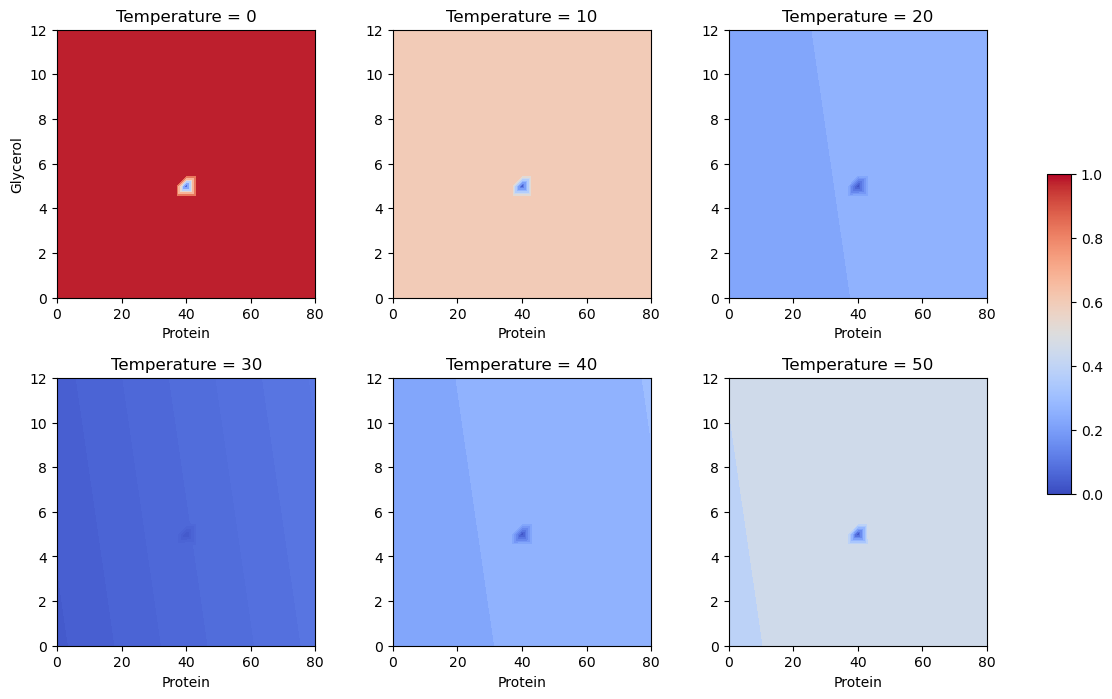

In [18]:
plot_value_slices(ds_result, "cost")

## Run AL

In [19]:
ds_running = ds_init.copy() 

n_steps = 50
pbar = tqdm(np.arange(n_steps))
for step in pbar:
    ds_result = p.calculate(ds_running, disable_progress_bar=True)

    next_sample = ds_result['next_sample'].to_pandas().to_dict(orient='records')[0]
    ds_new = inst_client.simple_expose(next_sample)
    ds_running = xr.concat([ds_running, ds_new], dim='sample')

  0%|          | 0/50 [00:00<?, ?it/s]

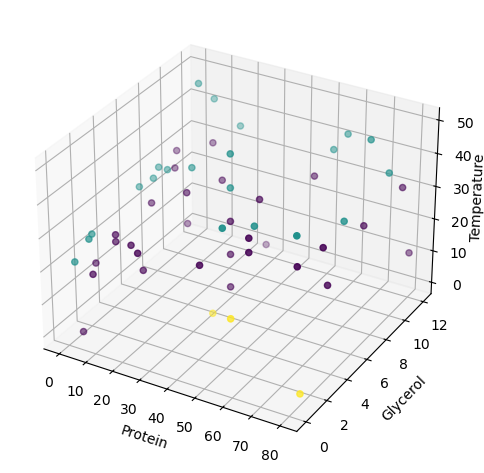

In [20]:
fig, ax  = plt.subplots(subplot_kw={"projection":'3d'})
ax.scatter(
    ds_result["composition"].sel(component='protein').values,
    ds_result["composition"].sel(component='glycerol').values,
    ds_result["composition"].sel(component='temperature').values,
    c=ds_result.labels.values
)
ax.set_xlabel('Protein')
ax.set_ylabel('Glycerol')
ax.set_zlabel('Temperature', labelpad=-2)
plt.tight_layout()
plt.show()

In [21]:
ds_result.composition

<xarray.DataArray 'composition' (sample: 55, component: 3)> Size: 1kB
array([[40.        ,  0.        ,  5.        ],
       [40.        , 10.        ,  5.        ],
       [40.        , 20.        ,  5.        ],
       [40.        , 30.        ,  5.        ],
       [40.        , 40.        ,  5.        ],
       [40.        , 50.        ,  5.        ],
       [40.        ,  0.        ,  5.        ],
       [76.66666667, 29.16666667,  8.        ],
       [20.        , 37.5       ,  6.5       ],
       [46.66666667, 31.25      ,  0.5       ],
       [50.        , 31.25      , 10.5       ],
       [10.        , 31.25      , 11.        ],
       [ 6.66666667, 31.25      ,  7.5       ],
       [ 3.33333333, 27.08333333,  1.5       ],
       [33.33333333,  0.        ,  5.        ],
       [20.        , 18.75      ,  2.        ],
       [60.        , 41.66666667,  2.        ],
       [10.        , 12.5       ,  8.5       ],
       [80.        , 25.        ,  3.5       ],
       [23.33333333, 29.16666667,  8.5       ],
...
       [ 3.33333333, 22.91666667,  0.        ],
       [80.        , 47.91666667,  0.5       ],
       [26.66666667,  0.        , 12.        ],
       [53.33333333, 37.5       , 11.5       ],
       [80.        , 39.58333333,  5.        ],
       [80.        , 37.5       ,  3.        ],
       [20.        , 29.16666667,  1.        ],
       [ 3.33333333, 31.25      ,  7.5       ],
       [60.        , 35.41666667,  1.5       ],
       [ 3.33333333, 29.16666667,  7.        ],
       [10.        , 20.83333333,  0.        ],
       [10.        , 25.        ,  2.        ],
       [60.        , 39.58333333,  1.5       ],
       [16.66666667, 35.41666667, 12.        ],
       [ 0.        , 29.16666667, 10.        ],
       [ 0.        , 27.08333333,  6.5       ],
       [56.66666667, 45.83333333,  0.        ],
       [10.        , 27.08333333,  2.        ],
       [46.66666667, 35.41666667,  6.        ],
       [20.        , 31.25      ,  6.        ]])
Coordinates:
  * component  (component) object 24B 'protein' 'temperature' 'glycerol'
Dimensions without coordinates: sample

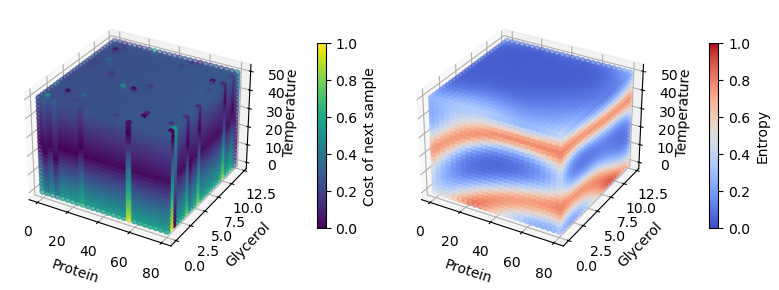

In [22]:
fig, axs  = plt.subplots(1,2, figsize=(4*2, 4), subplot_kw={"projection":'3d'})

norm = mcolors.Normalize(vmin=ds_result['cost'].min(), vmax=ds_result['cost'].max())
cmap = plt.get_cmap('viridis')
mappable = axs[0].scatter(
    ds_result["composition_grid"].sel(component='protein').values,
    ds_result["composition_grid"].sel(component='glycerol').values,
    ds_result["composition_grid"].sel(component='temperature').values,
    c=ds_result['cost'].values,
    cmap = cmap,
    norm = norm,
    s=20
)
cbar = fig.colorbar(mappable, ax=axs[0], shrink=0.5, pad=0.15)
cbar.set_label('Cost of next sample')

norm = mcolors.Normalize(vmin=0, vmax=1.0)
cmap = plt.get_cmap("coolwarm")
mappable = axs[1].scatter(
    ds_result["composition_grid"].sel(component='protein').values,
    ds_result["composition_grid"].sel(component='glycerol').values,
    ds_result["composition_grid"].sel(component='temperature').values,
    c=ds_result['extrap_y_prob'].values,
    cmap=cmap,
    norm = norm,
    s=20
)
cbar = fig.colorbar(mappable, ax=axs[1], shrink=0.5, pad=0.15)
cbar.set_label('Entropy')

for ax in axs:
    ax.set_xlabel('Protein')
    ax.set_ylabel('Glycerol')
    ax.set_zlabel('Temperature', labelpad=-2)
plt.tight_layout()
plt.show()

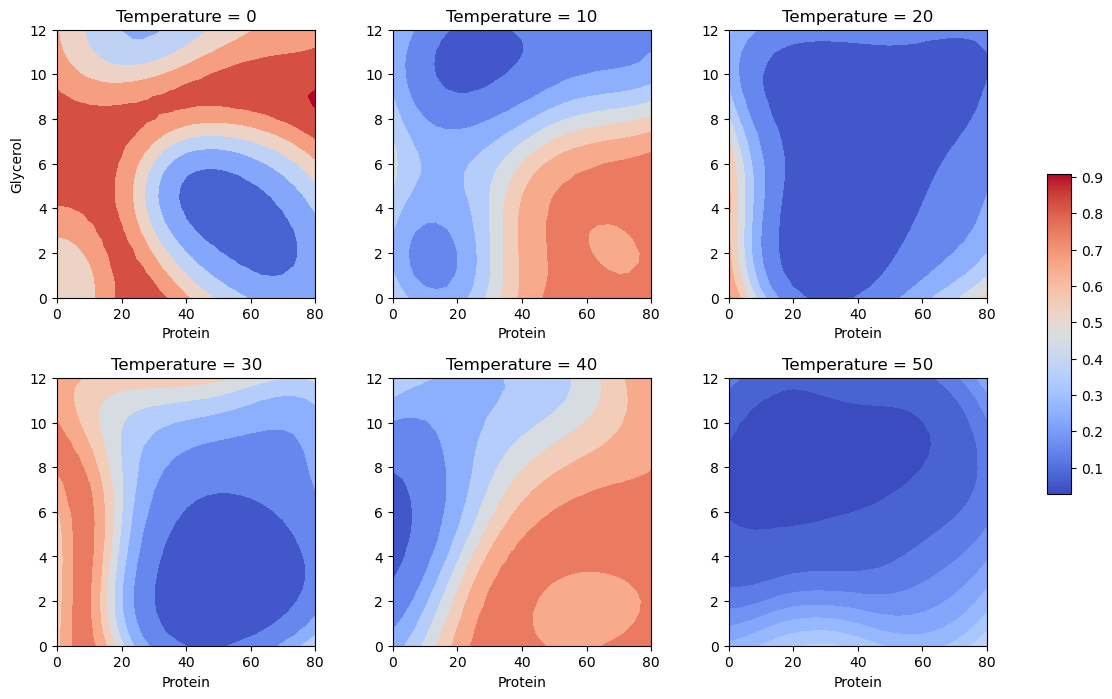

In [23]:
plot_value_slices(ds_result, "extrap_y_prob")

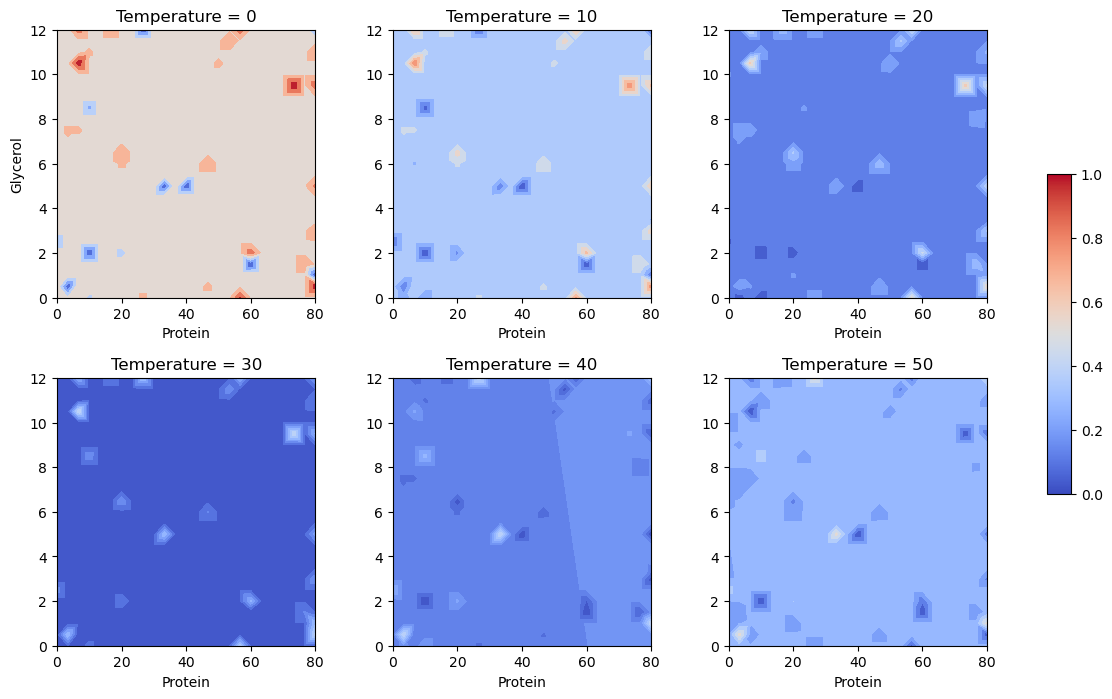

In [24]:
plot_value_slices(ds_result, "cost")

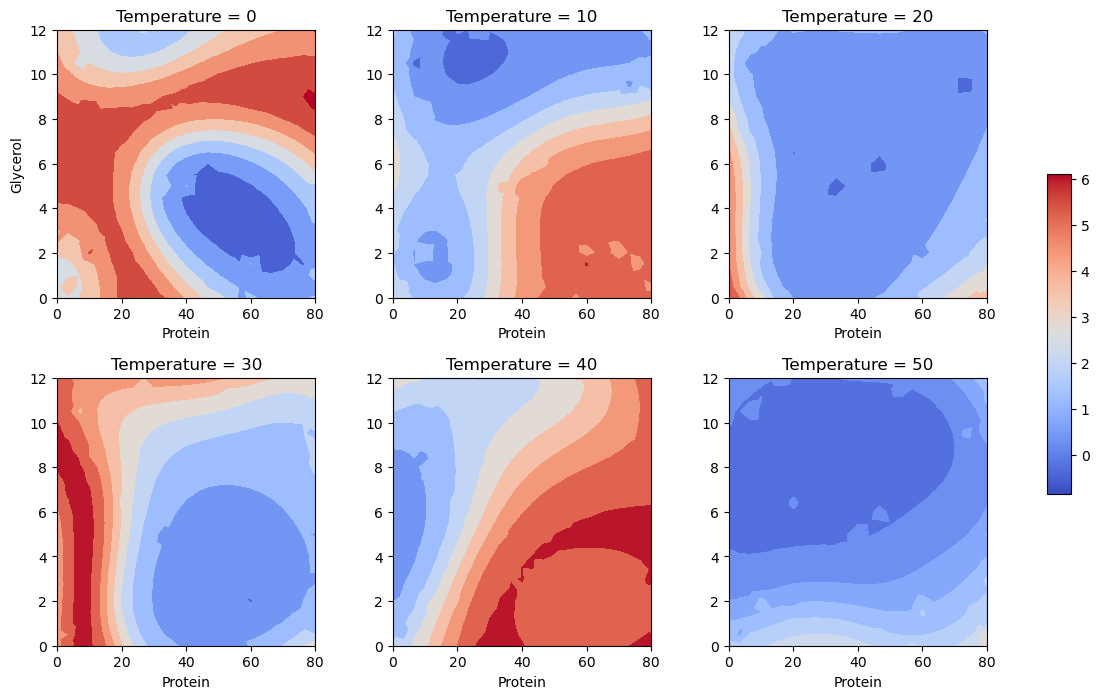

In [25]:
plot_value_slices(ds_result, "acqv_pu")

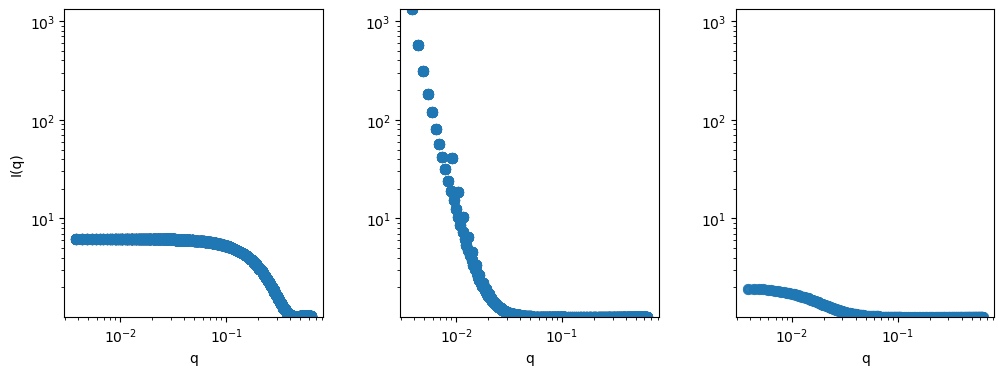

In [26]:
fig, axs = plt.subplots(1,3, figsize=(4*3, 4))
fig.subplots_adjust(wspace=0.3)
axs = axs.flatten()
q = ds_result.q.values 
Iq = ds_result.I.values
labels = ds_result.labels.values
for label in np.unique(labels):
    ax = axs[label]
    flags = labels == label
    Iq_current_phase = Iq[flags]
    for i in range(Iq_current_phase.shape[0]):
        ax.scatter(q, 
                  Iq_current_phase[i,:], 
                  color="tab:blue", 
                  lw=2.0, 
                  alpha=0.5
                )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("q")
    ax.set_ylim([Iq.min(), Iq.max()])
axs[0].set_ylabel("I(q)")
plt.show()